In [7]:
# CELL 1 — Setup
from google.colab import userdata
import os

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_USERNAME = "marcndo"
REPO_NAME = "churn-predictor"

!git clone https://github.com/marcndo/churn-predictor.git
os.chdir(f'/content/churn-predictor')
print("Working directory:", os.getcwd())

Cloning into 'churn-predictor'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 79 (delta 34), reused 67 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 819.12 KiB | 16.38 MiB/s, done.
Resolving deltas: 100% (34/34), done.
Working directory: /content/churn-predictor


In [9]:
# ============================================================
# CELL 2 — Install and download
# ============================================================
!pip install -r requirements.txt -q

import os
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)

!wget -q "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv" -O data/raw/Telco-Customer-Churn.csv
print("Setup complete")

data/raw/Telco-Customer-Churn.csv: No such file or directory
Setup complete


In [10]:
# ============================================================
# CELL 3 — Retrain to get the saved model
# (Colab sessions don't persist files between sessions)
# ============================================================
from src.data_processing import load_data, clean_data, split_data, build_preprocessor
from src.train import train_and_compare, select_best_model, train_final_model, save_model

df = load_data('data/Telco-Customer-Churn.csv')
df_clean = clean_data(df)
X_train, X_test, y_train, y_test = split_data(df_clean)
preprocessor = build_preprocessor()
all_results = train_and_compare(preprocessor, X_train, y_train)
best_name = select_best_model(all_results)
final_pipeline = train_final_model(best_name, preprocessor, X_train, y_train)
save_model(final_pipeline)

print("Model ready for evaluation")

Loaded 7043 rows and 21 columns
Data cleaned: 7043 row, 19 columns
Missing values after cleaned
Series([], dtype: int64)
Train set: 5634 rows
Test set: 1409 rows
Churn rate in train set: 26.54%
Churn rate in test set: 26.54%
MODEL COMPARISON-5-fold stratified Cross-Validation
Primary metric f1 Score

Training: Logistic Regression...
F1 Score: 0.5891 (±0.0333)
   Accuracy: 0.7994
   Roc-AUC: 0.8436302565192717
   Training Time: 2.325376272201538

Training: Random Forest...
F1 Score: 0.5291 (±0.0169)
   Accuracy: 0.7751
   Roc-AUC: 0.7984104657077664
   Training Time: 4.4937286376953125

Training: XGBoost...
F1 Score: 0.6319 (±0.0168)
   Accuracy: 0.7577
   Roc-AUC: 0.8449112601415661
   Training Time: 0.9249675273895264

BEST MODEL SELECTED
Winner:XGBoost
F1 Score: 0.6319(±0.0168)
Reason: Highest mean F1 accross 5 CV folds

Training final XGBoost on full training set...
Final model trained
Model save to models/best_model.joblib (167,186 bytes)
Model ready for evaluation


In [11]:
# ============================================================
# CELL 4 — Run final evaluation
# ============================================================
import joblib
from src.evaluate import (
    evaluate_model,
    print_report,
    plot_confusion_matrix,
    plot_feature_importance
)

# Load the saved pipeline
pipeline = joblib.load('models/best_model.joblib')

# Evaluate on test set — this happens ONCE
metrics, y_pred, y_prob = evaluate_model(pipeline, X_test, y_test)

# Print full report
print_report(metrics, y_test, y_pred)

# Confusion matrix
plot_confusion_matrix(y_test, y_pred)

# Feature importance
feature_names = X_train.columns.tolist()
plot_feature_importance(pipeline, feature_names)


FINAL TEST SET EVALUATION — XGBoost
  Accuracy:  0.7523
  Precision: 0.5221
  Recall:    0.7888
  F1 Score:  0.6283
  ROC-AUC:   0.8408

Detailed Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

Confusion matrix saved to data/confusion_matrix.png

Confusion matrix breakdown:
  True Negatives  (correctly predicted no churn): 765
  False Positives (false alarms):                 270
  False Negatives (missed churners):              79
  True Positives  (correctly caught churners):    295

  Of 374 actual churners, model caught 295 (78.9%)
  Of 565 predicted churners, 295 were correct (52.2%)


/content/churn-predictor/src/evaluate.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Feature importance plot saved to data/feature_importance.png

Top 5 most important features:
  categorical__Contract_Month-to-month: 0.4882
  categorical__InternetService_Fiber optic: 0.1160
  categorical__OnlineSecurity_No: 0.0650
  categorical__TechSupport_No: 0.0444
  categorical__StreamingMovies_Yes: 0.0323


Confusion Matrix:


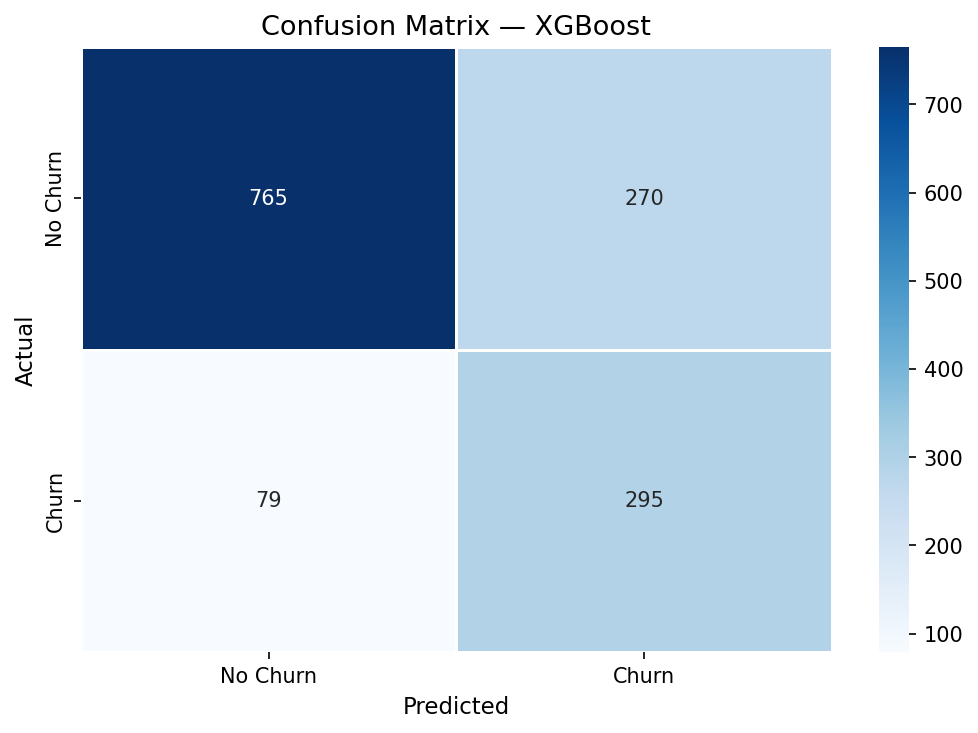


Feature Importance:


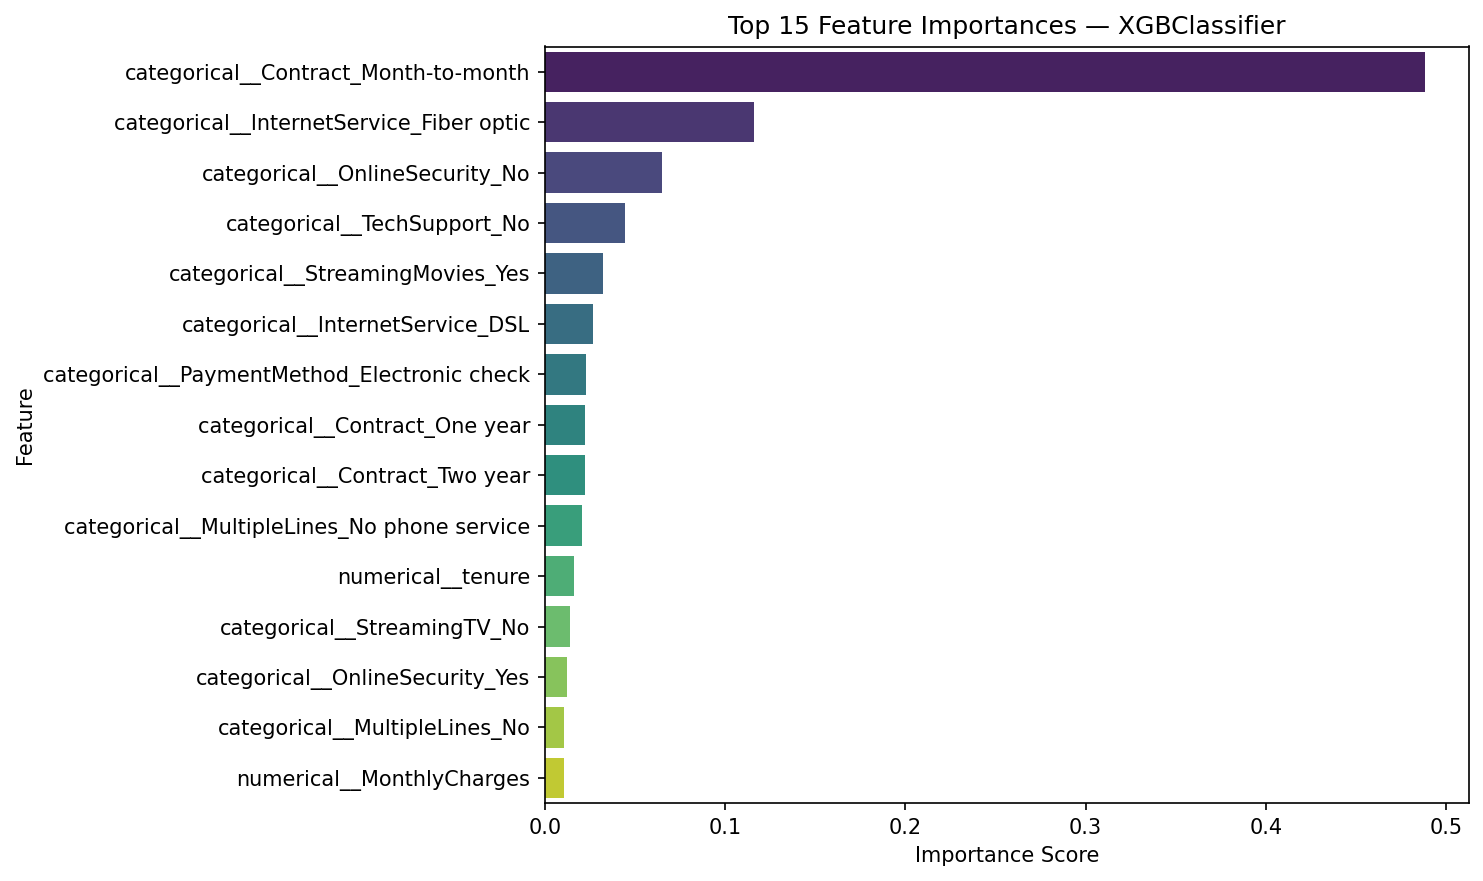

In [12]:
# ============================================================
# CELL 5 — Display plots inline
# ============================================================
from IPython.display import Image, display

print("Confusion Matrix:")
display(Image('data/confusion_matrix.png'))

print("\nFeature Importance:")
display(Image('data/feature_importance.png'))

In [13]:
from google.colab import files
files.download('models/best_model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# New Section